# Stage 1B: Image Extraction from PDFs

| Version | Date | Author | Description |
| --- | --- | --- | --- |
| 1.0.0 | 2026-01-26 | That Le | Extract images from arXiv PDFs |

---

## Overview

This notebook extracts images from collected PDF papers using PyMuPDF (fitz).

### Pipeline Position

```
01a_data_collection --> [01b_image_extraction] --> 01c_chart_classification --> 01d_qa_generation
                                 |
                                 v
                       Images in data/academic_dataset/images/
```

### Current Status

| Metric | Value |
| --- | --- |
| Source PDFs | ~889 |
| Extracted Images | ~2,852 |
| Avg Images/PDF | ~3.2 |

In [11]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Set to True to actually extract images
EXECUTE_EXTRACTION = True  # <-- Change to True to extract

# Extraction settings
MIN_IMAGE_SIZE = 100      # Minimum width/height in pixels
MAX_IMAGE_SIZE = 4096     # Maximum width/height in pixels
MIN_AREA = 10000          # Minimum pixel area (100x100)
QUALITY = 95              # JPEG quality for extracted images
SKIP_EXISTING = True      # Skip already extracted images

print(f"Extraction mode: {'ACTIVE' if EXECUTE_EXTRACTION else 'DRY RUN'}")

Extraction mode: ACTIVE


In [12]:
# ============================================================================
# ENVIRONMENT SETUP
# ============================================================================
import sys
from pathlib import Path
from datetime import datetime
import json

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Data directories
RAW_PDFS_DIR = PROJECT_ROOT / "data" / "raw_pdfs"
OUTPUT_IMAGES_DIR = PROJECT_ROOT / "data" / "academic_dataset" / "images"
METADATA_DIR = PROJECT_ROOT / "data" / "academic_dataset" / "metadata"
PROGRESS_FILE = PROJECT_ROOT / "data" / "extraction_progress.json"

# Ensure directories exist
OUTPUT_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"PDF source: {RAW_PDFS_DIR}")
print(f"Image output: {OUTPUT_IMAGES_DIR}")

Project root: d:\elix\chart_analysis_ai_v3
PDF source: d:\elix\chart_analysis_ai_v3\data\raw_pdfs
Image output: d:\elix\chart_analysis_ai_v3\data\academic_dataset\images


---

## 1. Current Dataset Statistics

In [13]:
# ============================================================================
# CHECK CURRENT DATASET
# ============================================================================

def get_extraction_stats():
    """Get statistics about current extraction status."""
    pdf_files = list(RAW_PDFS_DIR.glob("*.pdf")) if RAW_PDFS_DIR.exists() else []
    image_files = list(OUTPUT_IMAGES_DIR.glob("*.png")) + list(OUTPUT_IMAGES_DIR.glob("*.jpg"))
    
    # Estimate images per PDF
    unique_pdfs = set()
    for img in image_files:
        # Pattern: arxiv_xxxx_xxxx_page_X_img_Y.png
        parts = img.stem.split("_page_")
        if parts:
            unique_pdfs.add(parts[0])
    
    return {
        "total_pdfs": len(pdf_files),
        "total_images": len(image_files),
        "processed_pdfs": len(unique_pdfs),
        "avg_images_per_pdf": round(len(image_files) / len(unique_pdfs), 2) if unique_pdfs else 0,
        "pending_pdfs": len(pdf_files) - len(unique_pdfs),
    }

stats = get_extraction_stats()
print("=" * 50)
print("EXTRACTION STATISTICS")
print("=" * 50)
print(f"Total PDFs:          {stats['total_pdfs']:,}")
print(f"Processed PDFs:      {stats['processed_pdfs']:,}")
print(f"Pending PDFs:        {stats['pending_pdfs']:,}")
print(f"Total Images:        {stats['total_images']:,}")
print(f"Avg Images/PDF:      {stats['avg_images_per_pdf']}")
print("=" * 50)

EXTRACTION STATISTICS
Total PDFs:          9,508
Processed PDFs:      3,121
Pending PDFs:        6,387
Total Images:        3,121
Avg Images/PDF:      1.0


---

## 2. PDFMiner Class

Core class for extracting images from PDFs.

In [14]:
# ============================================================================
# PDFMINER CLASS
# ============================================================================
import io
import hashlib
from dataclasses import dataclass, field
from typing import List, Optional, Tuple

try:
    import fitz  # PyMuPDF
except ImportError:
    print("Installing PyMuPDF...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pymupdf", "-q"])
    import fitz

from PIL import Image
import numpy as np


@dataclass
class ExtractedImage:
    """Represents an extracted image."""
    image_id: str
    source_pdf: str
    page_number: int
    image_index: int
    width: int
    height: int
    format: str
    output_path: Optional[Path] = None
    caption: Optional[str] = None
    bbox: Optional[Tuple[float, float, float, float]] = None


class PDFMiner:
    """
    Extract images from PDF files.
    
    Uses PyMuPDF (fitz) for extraction with quality filtering.
    """
    
    def __init__(
        self,
        output_dir: Path,
        min_size: int = 100,
        max_size: int = 4096,
        min_area: int = 10000,
    ):
        self.output_dir = Path(output_dir)
        self.min_size = min_size
        self.max_size = max_size
        self.min_area = min_area
        self.output_dir.mkdir(parents=True, exist_ok=True)
    
    def extract_from_pdf(
        self,
        pdf_path: Path,
        skip_existing: bool = True,
    ) -> List[ExtractedImage]:
        """
        Extract all valid images from a PDF.
        
        Args:
            pdf_path: Path to PDF file
            skip_existing: Skip if images already extracted
            
        Returns:
            List of ExtractedImage objects
        """
        pdf_id = pdf_path.stem
        extracted = []
        
        try:
            doc = fitz.open(pdf_path)
        except Exception as e:
            print(f"Failed to open PDF | pdf={pdf_id} | error={e}")
            return []
        
        try:
            for page_num in range(len(doc)):
                page = doc[page_num]
                image_list = page.get_images(full=True)
                
                for img_idx, img_info in enumerate(image_list):
                    xref = img_info[0]
                    
                    # Generate unique image ID
                    image_id = f"{pdf_id}_page_{page_num + 1}_img_{img_idx + 1}"
                    output_path = self.output_dir / f"{image_id}.png"
                    
                    # Skip if exists
                    if skip_existing and output_path.exists():
                        continue
                    
                    # Extract image
                    try:
                        base_image = doc.extract_image(xref)
                        image_bytes = base_image["image"]
                        
                        # Load with PIL
                        pil_image = Image.open(io.BytesIO(image_bytes))
                        width, height = pil_image.size
                        
                        # Quality filtering
                        if not self._is_valid_image(width, height):
                            continue
                        
                        # Convert to RGB if needed
                        if pil_image.mode not in ["RGB", "L"]:
                            pil_image = pil_image.convert("RGB")
                        
                        # Save
                        pil_image.save(output_path, "PNG")
                        
                        extracted.append(ExtractedImage(
                            image_id=image_id,
                            source_pdf=pdf_id,
                            page_number=page_num + 1,
                            image_index=img_idx + 1,
                            width=width,
                            height=height,
                            format="PNG",
                            output_path=output_path,
                        ))
                        
                    except Exception as e:
                        # Skip problematic images silently
                        continue
                        
        finally:
            doc.close()
        
        return extracted
    
    def _is_valid_image(self, width: int, height: int) -> bool:
        """Check if image meets quality criteria."""
        # Size bounds
        if width < self.min_size or height < self.min_size:
            return False
        if width > self.max_size or height > self.max_size:
            return False
        
        # Minimum area
        if width * height < self.min_area:
            return False
        
        # Aspect ratio (filter out too narrow/wide images)
        aspect = max(width, height) / min(width, height)
        if aspect > 10:  # Too extreme aspect ratio
            return False
        
        return True


print("PDFMiner class defined.")

PDFMiner class defined.


---

## 3. Preview Extraction (Single PDF)

In [15]:
# ============================================================================
# PREVIEW EXTRACTION
# ============================================================================

def preview_extraction(pdf_dir: Path, num_samples: int = 3):
    """Preview extraction from a few PDFs without saving."""
    pdf_files = list(pdf_dir.glob("*.pdf"))[:num_samples]
    
    if not pdf_files:
        print("No PDF files found!")
        return
    
    print(f"Previewing extraction from {len(pdf_files)} PDFs...\n")
    
    for pdf in pdf_files:
        print(f"PDF: {pdf.name}")
        
        try:
            doc = fitz.open(pdf)
            total_images = 0
            valid_images = 0
            
            for page_num in range(min(len(doc), 10)):  # First 10 pages
                page = doc[page_num]
                images = page.get_images(full=True)
                total_images += len(images)
                
                for img_info in images:
                    try:
                        xref = img_info[0]
                        base_image = doc.extract_image(xref)
                        pil_image = Image.open(io.BytesIO(base_image["image"]))
                        w, h = pil_image.size
                        
                        if w >= MIN_IMAGE_SIZE and h >= MIN_IMAGE_SIZE and w * h >= MIN_AREA:
                            valid_images += 1
                    except:
                        pass
            
            doc.close()
            
            print(f"  Pages: {len(doc)} | Raw images: {total_images} | Valid: {valid_images}")
            
        except Exception as e:
            print(f"  Error: {e}")
        
        print()

# Run preview
preview_extraction(RAW_PDFS_DIR, num_samples=3)

Previewing extraction from 3 PDFs...

PDF: arxiv_0001065v2.pdf
  Error: document closed

PDF: arxiv_0001088v1.pdf
  Error: document closed

PDF: arxiv_0001424v1.pdf
  Error: document closed



---

## 4. Batch Extraction with Progress

In [16]:
# ============================================================================
# BATCH EXTRACTION
# ============================================================================
from typing import Dict, Any
import time


def load_extraction_progress() -> Dict[str, Any]:
    """Load extraction progress."""
    if PROGRESS_FILE.exists():
        with open(PROGRESS_FILE) as f:
            return json.load(f)
    return {"processed": [], "total_images": 0, "errors": []}


def save_extraction_progress(progress: Dict[str, Any]):
    """Save extraction progress."""
    with open(PROGRESS_FILE, "w") as f:
        json.dump(progress, f, indent=2)


def batch_extract(
    pdf_dir: Path,
    output_dir: Path,
    resume: bool = True,
    dry_run: bool = True,
    max_pdfs: int = None,
) -> Dict[str, Any]:
    """
    Extract images from all PDFs with progress tracking.
    
    Args:
        pdf_dir: Directory containing PDFs
        output_dir: Directory for extracted images
        resume: Resume from checkpoint
        dry_run: Don't actually extract
        max_pdfs: Maximum PDFs to process (None = all)
        
    Returns:
        Statistics dictionary
    """
    miner = PDFMiner(
        output_dir=output_dir,
        min_size=MIN_IMAGE_SIZE,
        max_size=MAX_IMAGE_SIZE,
        min_area=MIN_AREA,
    )
    
    # Load progress
    if resume:
        progress = load_extraction_progress()
    else:
        progress = {"processed": [], "total_images": 0, "errors": []}
    
    processed_set = set(progress["processed"])
    
    # Get PDF list
    pdf_files = sorted(pdf_dir.glob("*.pdf"))
    if max_pdfs:
        pdf_files = pdf_files[:max_pdfs]
    
    # Filter already processed
    pending = [p for p in pdf_files if p.stem not in processed_set]
    
    print("=" * 60)
    print(f"BATCH EXTRACTION | mode={'DRY RUN' if dry_run else 'ACTIVE'}")
    print(f"Total PDFs: {len(pdf_files)} | Pending: {len(pending)}")
    print("=" * 60)
    
    if dry_run:
        print("\n[DRY RUN] Would extract from pending PDFs...")
        print("Set EXECUTE_EXTRACTION = True to actually extract.")
        return progress
    
    start_time = time.time()
    batch_images = 0
    
    for idx, pdf_path in enumerate(pending, 1):
        try:
            # Extract
            images = miner.extract_from_pdf(pdf_path, skip_existing=SKIP_EXISTING)
            
            # Update progress
            progress["processed"].append(pdf_path.stem)
            progress["total_images"] += len(images)
            batch_images += len(images)
            
            # Progress output every 10 PDFs
            if idx % 10 == 0:
                elapsed = time.time() - start_time
                rate = idx / elapsed if elapsed > 0 else 0
                eta = (len(pending) - idx) / rate if rate > 0 else 0
                
                print(f"  [{idx}/{len(pending)}] Images extracted: {batch_images} | "
                      f"Rate: {rate:.1f} PDF/s | ETA: {eta/60:.1f}min")
                
                # Checkpoint
                save_extraction_progress(progress)
                
        except KeyboardInterrupt:
            print("\n[INTERRUPTED] Saving progress...")
            save_extraction_progress(progress)
            break
            
        except Exception as e:
            progress["errors"].append({"pdf": pdf_path.stem, "error": str(e)})
    
    # Final save
    save_extraction_progress(progress)
    
    elapsed = time.time() - start_time
    print("\n" + "=" * 60)
    print("EXTRACTION COMPLETE")
    print(f"  PDFs processed: {idx}")
    print(f"  Images extracted: {batch_images}")
    print(f"  Time: {elapsed/60:.1f} minutes")
    print(f"  Errors: {len(progress['errors'])}")
    print("=" * 60)
    
    return progress


print("batch_extract() function defined.")

batch_extract() function defined.


In [17]:
# ============================================================================
# EXECUTE EXTRACTION
# ============================================================================

if EXECUTE_EXTRACTION:
    print("Starting batch extraction...")
    print("Press Ctrl+C to interrupt (progress will be saved).")
    print()
    
    result = batch_extract(
        pdf_dir=RAW_PDFS_DIR,
        output_dir=OUTPUT_IMAGES_DIR,
        resume=True,
        dry_run=False,
    )
else:
    print("[SKIPPED] Extraction not executed.")
    print("Set EXECUTE_EXTRACTION = True at the top to enable extraction.")
    print("\nTo extract manually, run:")
    print("  batch_extract(RAW_PDFS_DIR, OUTPUT_IMAGES_DIR, dry_run=False)")

Starting batch extraction...
Press Ctrl+C to interrupt (progress will be saved).

BATCH EXTRACTION | mode=ACTIVE
Total PDFs: 9508 | Pending: 9508
  [10/9508] Images extracted: 0 | Rate: 90.0 PDF/s | ETA: 1.8min
  [20/9508] Images extracted: 19 | Rate: 62.3 PDF/s | ETA: 2.5min
  [30/9508] Images extracted: 65 | Rate: 44.2 PDF/s | ETA: 3.6min
  [40/9508] Images extracted: 65 | Rate: 48.6 PDF/s | ETA: 3.2min
  [50/9508] Images extracted: 72 | Rate: 50.6 PDF/s | ETA: 3.1min
  [60/9508] Images extracted: 73 | Rate: 52.0 PDF/s | ETA: 3.0min
  [70/9508] Images extracted: 73 | Rate: 53.9 PDF/s | ETA: 2.9min
  [80/9508] Images extracted: 75 | Rate: 54.6 PDF/s | ETA: 2.9min
  [90/9508] Images extracted: 106 | Rate: 52.1 PDF/s | ETA: 3.0min
  [100/9508] Images extracted: 115 | Rate: 51.3 PDF/s | ETA: 3.1min
  [110/9508] Images extracted: 124 | Rate: 46.6 PDF/s | ETA: 3.4min
  [120/9508] Images extracted: 134 | Rate: 46.8 PDF/s | ETA: 3.3min
  [130/9508] Images extracted: 168 | Rate: 35.5 PDF/s | 

d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (128400000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (161464800 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (150645600 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  [1390/9508] Images extracted: 16333 | Rate: 2.0 PDF/s | ETA: 66.2min
  [1400/9508] Images extracted: 16514 | Rate: 2.0 PDF/s | ETA: 67.4min
  [1410/9508] Images extracted: 16634 | Rate: 2.0 PDF/s | ETA: 68.0min
  [1420/9508] Images extracted: 16791 | Rate: 2.0 PDF/s | ETA: 68.0min
  [1430/9508] Images extracted: 16874 | Rate: 2.0 PDF/s | ETA: 68.5min
  [1440/9508] Images extracted: 16952 | Rate: 1.9 PDF/s | ETA: 69.2min
  [1450/9508] Images extracted: 17221 | Rate: 1.9 PDF/s | ETA: 69.5min
  [1460/9508] Images extracted: 17373 | Rate: 1.9 PDF/s | ETA: 71.0min
  [1470/9508] Images extracted: 17604 | Rate: 1.9 PDF/s | ETA: 71.4min
  [1480/9508] Images extracted: 17665 | Rate: 1.9 PDF/s | ETA: 71.1min
  [1490/9508] Images extracted: 17745 | Rate: 1.9 PDF/s | ETA: 70.8min
  [1500/9508] Images extracted: 17938 | Rate: 1.9 PDF/s | ETA: 71.8min
  [1510/9508] Images extracted: 18002 | Rate: 1.9 PDF/s | ETA: 71.6min
  [1520/9508] Images extracted: 18104 | Rate: 1.9 PDF/s | ETA: 71.2min
  [153

d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (93817284 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (97771737 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  [1720/9508] Images extracted: 20355 | Rate: 1.7 PDF/s | ETA: 77.2min
  [1730/9508] Images extracted: 20412 | Rate: 1.7 PDF/s | ETA: 77.0min
  [1740/9508] Images extracted: 20481 | Rate: 1.7 PDF/s | ETA: 76.8min
  [1750/9508] Images extracted: 20723 | Rate: 1.7 PDF/s | ETA: 77.2min
  [1760/9508] Images extracted: 20805 | Rate: 1.7 PDF/s | ETA: 78.0min
  [1770/9508] Images extracted: 20887 | Rate: 1.7 PDF/s | ETA: 77.9min
  [1780/9508] Images extracted: 20950 | Rate: 1.7 PDF/s | ETA: 77.8min
  [1790/9508] Images extracted: 21006 | Rate: 1.7 PDF/s | ETA: 77.7min
  [1800/9508] Images extracted: 21086 | Rate: 1.6 PDF/s | ETA: 78.1min
  [1810/9508] Images extracted: 21232 | Rate: 1.6 PDF/s | ETA: 78.3min
  [1820/9508] Images extracted: 21321 | Rate: 1.6 PDF/s | ETA: 78.5min
  [1830/9508] Images extracted: 21580 | Rate: 1.6 PDF/s | ETA: 79.5min
  [1840/9508] Images extracted: 21731 | Rate: 1.6 PDF/s | ETA: 79.6min
  [1850/9508] Images extracted: 21873 | Rate: 1.6 PDF/s | ETA: 79.7min
  [186

...

  [9300/9508] Images extracted: 193221 | Rate: 0.7 PDF/s | ETA: 5.3min
  [9310/9508] Images extracted: 193267 | Rate: 0.7 PDF/s | ETA: 5.1min
  [9320/9508] Images extracted: 193384 | Rate: 0.7 PDF/s | ETA: 4.8min
  [9330/9508] Images extracted: 194026 | Rate: 0.7 PDF/s | ETA: 4.6min
  [9340/9508] Images extracted: 194545 | Rate: 0.7 PDF/s | ETA: 4.3min
  [9350/9508] Images extracted: 194693 | Rate: 0.7 PDF/s | ETA: 4.0min
  [9360/9508] Images extracted: 194927 | Rate: 0.7 PDF/s | ETA: 3.8min


d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (138000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  [9370/9508] Images extracted: 195077 | Rate: 0.7 PDF/s | ETA: 3.5min
  [9380/9508] Images extracted: 195222 | Rate: 0.7 PDF/s | ETA: 3.3min


d:\elix\chart_analysis_ai_v3\.venv\Lib\site-packages\PIL\Image.py:3451: DecompressionBombWarning: Image size (99395420 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


  [9390/9508] Images extracted: 195407 | Rate: 0.7 PDF/s | ETA: 3.0min
  [9400/9508] Images extracted: 195598 | Rate: 0.6 PDF/s | ETA: 2.8min
  [9410/9508] Images extracted: 195676 | Rate: 0.7 PDF/s | ETA: 2.5min
  [9420/9508] Images extracted: 195696 | Rate: 0.7 PDF/s | ETA: 2.3min
  [9430/9508] Images extracted: 195702 | Rate: 0.7 PDF/s | ETA: 2.0min
  [9440/9508] Images extracted: 195702 | Rate: 0.7 PDF/s | ETA: 1.7min
  [9450/9508] Images extracted: 195706 | Rate: 0.7 PDF/s | ETA: 1.5min
  [9460/9508] Images extracted: 195706 | Rate: 0.7 PDF/s | ETA: 1.2min
  [9470/9508] Images extracted: 195708 | Rate: 0.7 PDF/s | ETA: 1.0min
  [9480/9508] Images extracted: 195708 | Rate: 0.7 PDF/s | ETA: 0.7min
  [9490/9508] Images extracted: 195709 | Rate: 0.7 PDF/s | ETA: 0.5min
  [9500/9508] Images extracted: 195709 | Rate: 0.7 PDF/s | ETA: 0.2min

EXTRACTION COMPLETE
  PDFs processed: 9508
  Images extracted: 195766
  Time: 241.4 minutes
  Errors: 0


---

## 5. Image Quality Analysis

In [21]:
# ============================================================================
# ANALYZE EXTRACTED IMAGES
# ============================================================================
import random

def analyze_images(image_dir: Path, sample_size: int = 100):
    """Analyze quality of extracted images."""
    image_files = list(image_dir.glob("*.png")) + list(image_dir.glob("*.jpg"))
    
    if not image_files:
        print("No images found!")
        return
    
    # Sample for analysis
    samples = random.sample(image_files, min(sample_size, len(image_files)))
    
    widths = []
    heights = []
    sizes_kb = []
    
    for img_path in samples:
        try:
            img = Image.open(img_path)
            widths.append(img.size[0])
            heights.append(img.size[1])
            sizes_kb.append(img_path.stat().st_size / 1024)
            img.close()
        except:
            pass
    
    print("=" * 50)
    print("IMAGE QUALITY ANALYSIS")
    print(f"(Based on {len(widths)} samples)")
    print("=" * 50)
    print(f"Width:   min={min(widths)}, max={max(widths)}, avg={np.mean(widths):.0f}")
    print(f"Height:  min={min(heights)}, max={max(heights)}, avg={np.mean(heights):.0f}")
    print(f"Size:    min={min(sizes_kb):.0f}KB, max={max(sizes_kb):.0f}KB, avg={np.mean(sizes_kb):.0f}KB")
    print("=" * 50)
    
    # Size distribution
    small = sum(1 for w, h in zip(widths, heights) if w < 300 or h < 300)
    medium = sum(1 for w, h in zip(widths, heights) if 300 <= w < 800 and 300 <= h < 800)
    large = sum(1 for w, h in zip(widths, heights) if w >= 800 or h >= 800)
    
    print("\nSize Distribution:")
    print(f"  Small (<300px):    {small} ({small/len(widths)*100:.1f}%)")
    print(f"  Medium (300-800):  {medium} ({medium/len(widths)*100:.1f}%)")
    print(f"  Large (>800px):    {large} ({large/len(widths)*100:.1f}%)")

# Run analysis
analyze_images(OUTPUT_IMAGES_DIR)

IMAGE QUALITY ANALYSIS
(Based on 100 samples)
Width:   min=102, max=3543, avg=645
Height:  min=101, max=2144, avg=480
Size:    min=0KB, max=2366KB, avg=201KB

Size Distribution:
  Small (<300px):    46 (46.0%)
  Medium (300-800):  30 (30.0%)
  Large (>800px):    25 (25.0%)


---

## 6. Sample Image Visualization

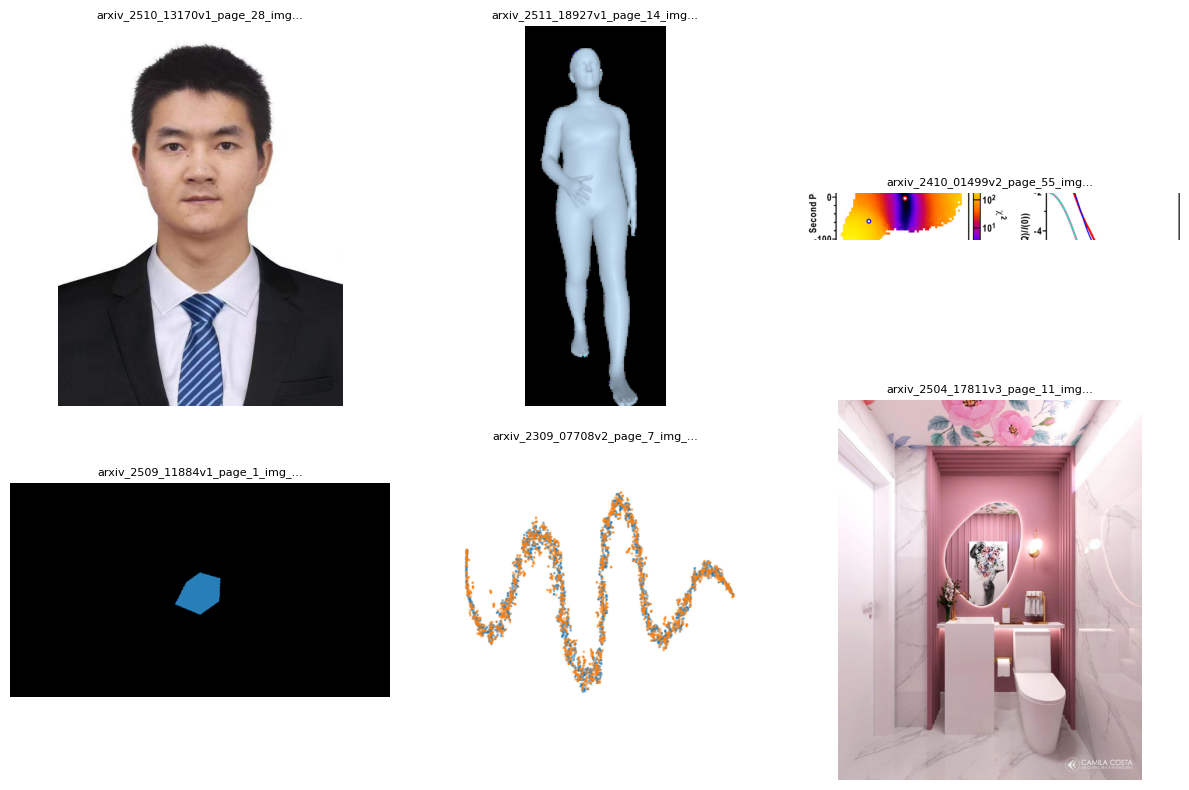

In [22]:
# ============================================================================
# VISUALIZE SAMPLES
# ============================================================================
import matplotlib.pyplot as plt

def show_sample_images(image_dir: Path, num_samples: int = 6):
    """Display random sample of extracted images."""
    image_files = list(image_dir.glob("*.png")) + list(image_dir.glob("*.jpg"))
    
    if not image_files:
        print("No images found!")
        return
    
    samples = random.sample(image_files, min(num_samples, len(image_files)))
    
    cols = 3
    rows = (num_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows))
    axes = axes.flatten() if num_samples > 1 else [axes]
    
    for ax, img_path in zip(axes, samples):
        try:
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(img_path.stem[:30] + "...", fontsize=8)
            ax.axis("off")
        except Exception as e:
            ax.text(0.5, 0.5, f"Error: {e}", ha="center", va="center")
            ax.axis("off")
    
    # Hide empty axes
    for ax in axes[len(samples):]:
        ax.axis("off")
    
    plt.tight_layout()
    plt.show()

# Show samples
show_sample_images(OUTPUT_IMAGES_DIR, num_samples=6)

---

## 7. Generate Extraction Report

In [23]:
# ============================================================================
# EXTRACTION REPORT
# ============================================================================

def generate_extraction_report():
    """Generate comprehensive extraction report."""
    stats = get_extraction_stats()
    progress = load_extraction_progress()
    
    # Calculate total image size
    image_files = list(OUTPUT_IMAGES_DIR.glob("*.png")) + list(OUTPUT_IMAGES_DIR.glob("*.jpg"))
    total_size_mb = sum(f.stat().st_size for f in image_files) / (1024 * 1024)
    
    report = f"""
================================================================================
                       IMAGE EXTRACTION REPORT
                       {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}
================================================================================

SOURCE DATA
-----------
Total PDFs:           {stats['total_pdfs']:,}
Processed PDFs:       {stats['processed_pdfs']:,}
Pending PDFs:         {stats['pending_pdfs']:,}

EXTRACTED IMAGES
----------------
Total Images:         {stats['total_images']:,}
Total Size:           {total_size_mb:,.1f} MB
Avg Images/PDF:       {stats['avg_images_per_pdf']}
Avg Image Size:       {total_size_mb * 1024 / stats['total_images']:.1f} KB (per image)

QUALITY FILTERS
---------------
Min Size:             {MIN_IMAGE_SIZE}px
Max Size:             {MAX_IMAGE_SIZE}px
Min Area:             {MIN_AREA}px

ERRORS
------
Failed PDFs:          {len(progress.get('errors', []))}

================================================================================
NEXT STEPS
================================================================================
1. Run 01c_chart_classification.ipynb to filter charts from non-charts
2. Run 01d_qa_generation.ipynb to generate QA pairs
================================================================================
"""
    
    print(report)
    
    # Save report
    report_path = METADATA_DIR / f"extraction_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"
    report_path.write_text(report)
    print(f"Report saved to: {report_path}")


# Generate report
generate_extraction_report()


                       IMAGE EXTRACTION REPORT
                       2026-01-27 20:44:21

SOURCE DATA
-----------
Total PDFs:           9,508
Processed PDFs:       10,688
Pending PDFs:         -1,180

EXTRACTED IMAGES
----------------
Total Images:         198,887
Total Size:           50,392.4 MB
Avg Images/PDF:       18.61
Avg Image Size:       259.5 KB (per image)

QUALITY FILTERS
---------------
Min Size:             100px
Max Size:             4096px
Min Area:             10000px

ERRORS
------
Failed PDFs:          0

NEXT STEPS
1. Run 01c_chart_classification.ipynb to filter charts from non-charts
2. Run 01d_qa_generation.ipynb to generate QA pairs

Report saved to: d:\elix\chart_analysis_ai_v3\data\academic_dataset\metadata\extraction_report_20260127_204421.txt


---

## Summary

### Functions Provided

| Function | Purpose |
| --- | --- |
| `PDFMiner.extract_from_pdf()` | Extract images from single PDF |
| `batch_extract()` | Batch extraction with checkpoints |
| `analyze_images()` | Quality statistics for images |
| `show_sample_images()` | Visualize sample images |

### Quality Filters Applied

- Minimum size: 100x100 pixels
- Maximum size: 4096x4096 pixels
- Minimum area: 10,000 pixels
- Aspect ratio < 10:1

### Output

- Images saved to: `data/academic_dataset/images/`
- Naming pattern: `arxiv_<id>_page_<N>_img_<M>.png`

---

**Next**: [01c_chart_classification.ipynb](01c_chart_classification.ipynb)